# California EV Charging Equity Analysis 

## Overview 
This notebook analyzes whether public EV charging infrastructure is keeping pace with the electric vehicle adoption across California counties, and examines the role income plays in that relationship. 

## Research Question 
Are lower-income California counties being underserved by public charging infrastructure relative to their EV adoption rates? 

## Data Sources 
- **EV Registrations** Calfornia DMV via data.ca.gov (2025) 
- **Charging Stations:** Alternative Fuels Data Center, U.S. DOE (2025)
- **Per Capita Income:** Bureau of Economic Analysis, CAINC1 (2024)

## Pipeline 
1. Data loading and SQL queries 
2. Zip-to-country aggregation and merging
3. Exploratory Data Analysis (EDA) 
4. OLS Regression 
5. Random Forest Model 
6. Model Comparison

In [2]:
import sqlite3
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from statsmodels.formula.api import ols 
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

## 1. Data Loading & SQL Queries 
Connecting to the local SQLite database and pulling cleaned, aggregated data for EV registrations, charging stations, and county income using SQL. 

In [3]:
conn = sqlite3.connect('ev_equity.db')

# Pull EV registrations (BEV + PHEV) by zip
query_ev = """ 
    SELECT 
        "ZIP Code" as zip, 
        SUM(Vehicles) as ev_count
    FROM ev_registrations 
    WHERE Fuel IN ('Battery Electric', 'Plug-in Hybrid')
    GROUP BY "ZIP Code"
"""
ev_by_zip = pd.read_sql_query(query_ev, conn)

# Pull Charging ports by zip
query_chargers = """ 
    SELECT
        ZIP as zip, 
        COUNT(*) as station_count,
        SUM(COALESCE("EV Level2 EVSE Num", 0) +
            COALESCE("EV DC Fast Count", 0)) as total_ports
    FROM charging_stations 
    GROUP BY ZIP
"""
chargers_by_zip = pd.read_sql_query(query_chargers, conn)

# Pull per capita income by county (2024)
query_income = """ 
    SELECT
        GeoName as county, 
        "2024" as per_capita_income
    FROM county_income
    WHERE LineCode = 3
    AND GeoName != 'California'
"""
income_by_county = pd.read_sql_query(query_income, conn)

conn.close()

## 2. Zip-to-County Mapping & Data Merging
EV registrations and charging stations are recorded at the zip code level, while incoem data is at the county level. We map zips to counties using a crosswalk, then aggregrate and merge all three datasets into a single county-level analysis table. 

In [4]:
# Note: The crosswalk file was originally fetched directly from GitHub using 
# pd.read_csv() with a remote URL. This approach raised an SSL certificate 
# verification error on macOS Python 3.13 (SSLCertVerificationError). 
# The file was downloaded manually instead and loaded locally — see next cell.

# import ssl
# ssl._create_default_https_context = ssl._create_unverified_context

# crosswalk = pd.read_csv(
#     'https://raw.githubusercontent.com/scpike/us-state-county-zip/master/geo-data.csv',
#     dtype={'zipcode': str}
# )

# crosswalk_ca = crosswalk[crosswalk['state'] == 'CA'][['zipcode', 'county']]

In [5]:
# Load zip-to-county crosswalk from local file
crosswalk = pd.read_csv('crosswalk.csv', dtype={'zipcode': str})

# Filter to California only
crosswalk_ca = crosswalk[crosswalk['state'] == 'California'][['zipcode', 'county']]

print(crosswalk_ca.head())
print(crosswalk_ca.shape)

     zipcode       county
1902   89439       Sierra
1903   90001  Los Angeles
1904   90002  Los Angeles
1905   90003  Los Angeles
1906   90004  Los Angeles
(1757, 2)


In [6]:
# Merge EV registrations with crosswalk to get county
ev_by_zip['zip'] = ev_by_zip['zip'].astype(str).str.zfill(5)
chargers_by_zip['zip'] = chargers_by_zip['zip'].astype(str).str.zfill(5)
crosswalk_ca['zipcode'] = crosswalk_ca['zipcode'].astype(str).str.zfill(5)

# Join EV and chargers to crosswalk
ev_county = ev_by_zip.merge(crosswalk_ca, left_on='zip', right_on='zipcode', how='left')
chargers_county = chargers_by_zip.merge(crosswalk_ca, left_on='zip', right_on='zipcode', how='left')

# Aggregate to county level
ev_by_county = ev_county.groupby('county')['ev_count'].sum().reset_index()
chargers_by_county = chargers_county.groupby('county')[['station_count', 'total_ports']].sum().reset_index()

# Clean income county names (strip ", CA")
income_by_county['county'] = income_by_county['county'].str.replace(', CA', '', regex=False).str.strip()

# Merge all three into one analysis table
df = ev_by_county.merge(chargers_by_county, on='county', how='inner')
df = df.merge(income_by_county, on='county', how='inner')

print(df.shape)
print(df.head(10))

(58, 5)
         county  ev_count  station_count  total_ports  per_capita_income
0       Alameda    135075            842       2597.0           111268.0
1        Alpine        39              6         18.0            88146.0
2        Amador       819             14         38.0            53703.0
3         Butte      3647             51        172.0            61191.0
4     Calaveras      1074              9         44.0            64051.0
5        Colusa       231             11         98.0            61656.0
6  Contra Costa     69270            322       1081.0           108259.0
7     Del Norte       259             16         46.0            50144.0
8     El Dorado      9112             77        270.0            89554.0
9        Fresno     16542            268        833.0            57584.0


Alameda with 135,075 EVs and 2597 ports vs Del Norte with just 259 EVs and 46 ports. We see the story emerging from just the first ten rows. 

## 3. Exploratory Data Analysis (EDA)
Examining distributions, relationships, and outliers across our five variables before modeling. Key question: does income correlate with charging access relative to EV adoption? 

In [7]:
# Basic summary statistics
df.describe() 

,ev_count,station_count,total_ports,per_capita_income
count,58.000000,58.000000,58.000000,58.000000
mean,36444.913793,317.879310,1056.086207,75701.741379
std,87027.824437,715.731403,2516.733202,31702.842798
min,37.000000,3.000000,3.000000,42191.000000
25%,859.250000,14.500000,81.000000,56479.000000
50%,4028.000000,79.500000,255.500000,65897.500000
75%,25243.750000,237.250000,808.750000,84206.000000
max,557503.000000,4583.000000,17157.000000,190891.000000


The EV count mean is 36,444 but the max is 557,503, and the standard deviation is 87,027, more than double the mean. That tells you the distribution is heavily righthand skewed, meaning a handful of counties (LA, Santa Clara, Orange) are dominiating the numbers

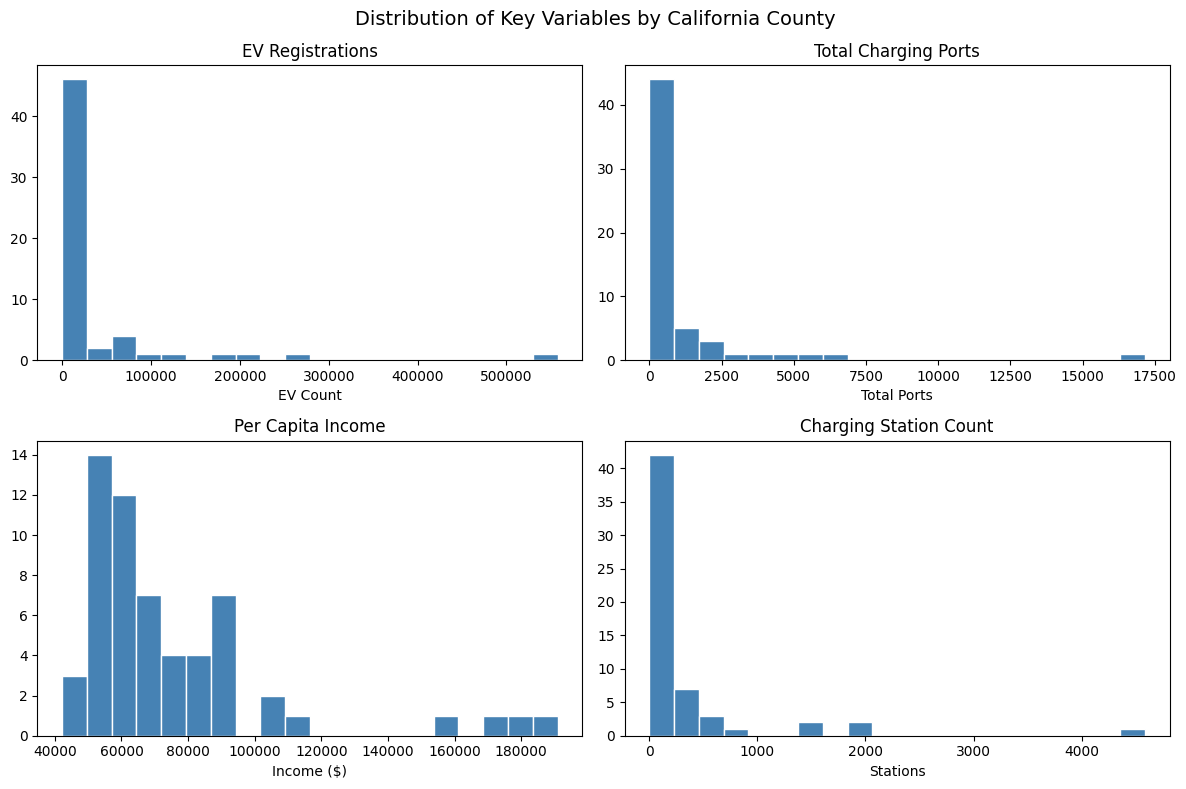

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribution of Key Variables by California County', fontsize=14)

axes[0, 0].hist(df['ev_count'], bins=20, color='steelblue', edgecolor='white')
axes[0, 0].set_title('EV Registrations')
axes[0, 0].set_xlabel('EV Count')

axes[0, 1].hist(df['total_ports'], bins=20, color='steelblue', edgecolor='white')
axes[0, 1].set_title('Total Charging Ports')
axes[0, 1].set_xlabel('Total Ports')

axes[1, 0].hist(df['per_capita_income'], bins=20, color='steelblue', edgecolor='white')
axes[1, 0].set_title('Per Capita Income')
axes[1, 0].set_xlabel('Income ($)')

axes[1, 1].hist(df['station_count'], bins=20, color='steelblue', edgecolor='white')
axes[1, 1].set_title('Charging Station Count')
axes[1, 1].set_xlabel('Stations')

plt.tight_layout()
plt.show()

The histograms confirm our suspicions. The mass of counties are clustered near zero with LA, Santa Clara, and Orange County being the massive outliers. The skewness in the EV and charger variables means we'll want to apply a log transformation before modeling; this will compress those outliers and give the regression cleaner, more interpretable results.

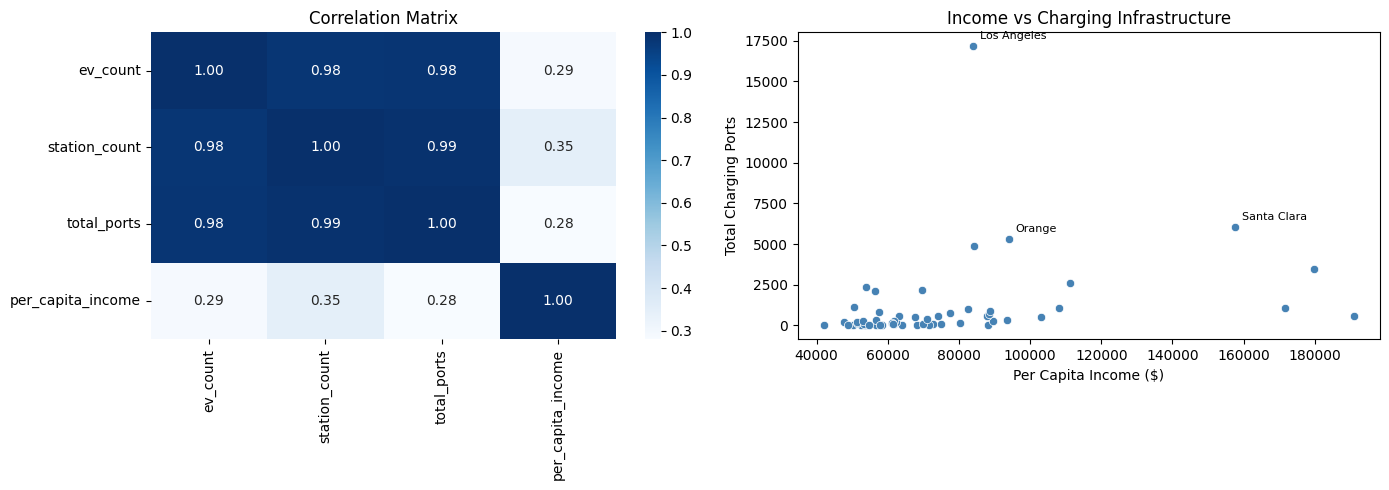

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation heatmap
corr = df[['ev_count', 'station_count', 'total_ports', 'per_capita_income']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', ax=axes[0])
axes[0].set_title('Correlation Matrix')

# Income vs charging ports scatter
axes[1].scatter(df['per_capita_income'], df['total_ports'], 
                color='steelblue', edgecolors='white', linewidth=0.5)
axes[1].set_xlabel('Per Capita Income ($)')
axes[1].set_ylabel('Total Charging Ports')
axes[1].set_title('Income vs Charging Infrastructure')

# Label a few notable counties
for _, row in df.nlargest(3, 'total_ports').iterrows():
    axes[1].annotate(row['county'], 
                     (row['per_capita_income'], row['total_ports']),
                     textcoords='offset points', xytext=(5, 5), fontsize=8)

plt.tight_layout()
plt.show()

EV count, station count, and total ports are almost perfecly correlated with each other (0.98-0.99). More EVs in an area means more demand and more infrastructure.

Income's correlation with the charging variables is weak at 0.28 to 0.35. And the scatter plot shows why: LA is a massive outlier sitting at a relatively average income (~$85k) but dominates in charging ports; distorting the relationship. This will become more clear once we log-transform and control for EV adoption in the regression. 

This is actualy a good analytical finding on its own - raw infrastructure counts are driven more by population/adoption scale than income. Question now is whether counties are getting _proportionally_ adequate charging relative to their EV counts, and whether income predicts that gap. 

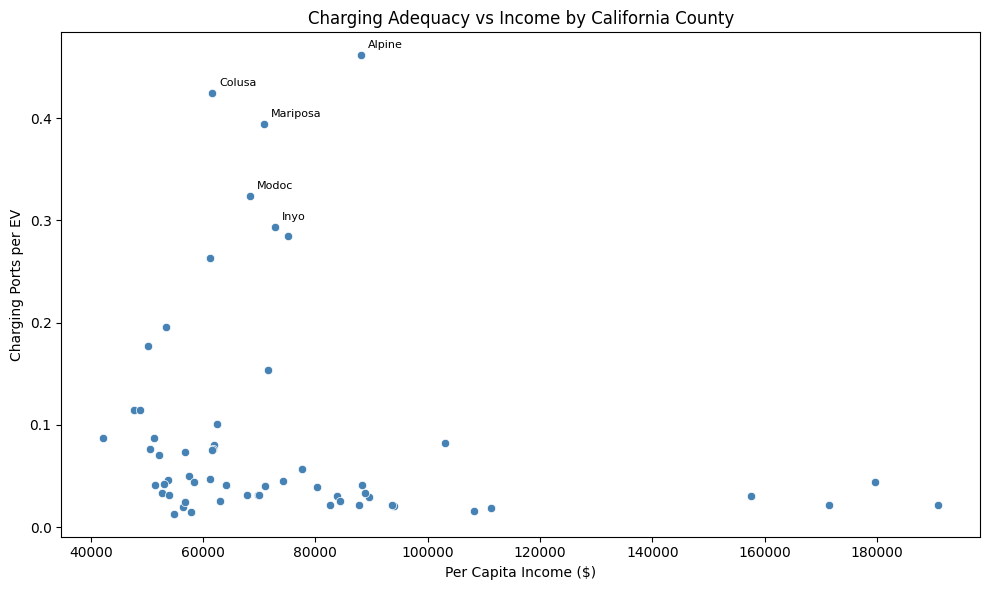

In [11]:
# Create ports-per-EV ratio (charging adequacy metric)
df['ports_per_ev'] = df['total_ports'] / df['ev_count']

# Log transform skewed variables for modeling
df['log_ev_count'] = np.log1p(df['ev_count'])
df['log_total_ports'] = np.log1p(df['total_ports'])
df['log_income'] = np.log(df['per_capita_income'])

# Plot ports per EV by income
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['per_capita_income'], df['ports_per_ev'],
           color='steelblue', edgecolors='white', linewidth=0.5)
ax.set_xlabel('Per Capita Income ($)')
ax.set_ylabel('Charging Ports per EV')
ax.set_title('Charging Adequacy vs Income by California County')

for _, row in df.nlargest(5, 'ports_per_ev').iterrows():
    ax.annotate(row['county'],
                (row['per_capita_income'], row['ports_per_ev']),
                textcoords='offset points', xytext=(5, 5), fontsize=8)

plt.tight_layout()
plt.show()

Alpine, Colusa, Mariposa, Modoc, and Inyo are leading on ports per EV but these are tiny rural counties with a very few EVs total, so a handful of highway charging stations inflates their ratio. 

The more telling pattern is on the right side of the chart. The highest income counties like Santa Clara (~$160k), Marin(~$170k), and San Mateo (~$190k) all have very low ports per EV despite being wealthy. Suggesting high-income counties' infrastructure hasn't kept pace with EV adoption, which is a counterintuitive and interesting finding. 

The bulk of mid-income counties cluster near the bottom between 0.02 and 0.10 ports per EV, showing broadly inadequate charging relative to adoption regardless of income level. 

## 4. OLS Regression 
Modeling the relationship between per capita income and charging adequacy (ports per EV) at the county level, controlling for EV adoption scale using log-transformed variables to address right skew. 

In [12]:
import statsmodels.api as sm 

# Define variables 
X = df[['log_income', 'log_ev_count']]
y = df['log_total_ports']

# Add constant for intercept 
X = sm.add_constant(X)

# Fit OLS model 
ols_model = sm.OLS(y, X).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:        log_total_ports   R-squared:                       0.890
Model:                            OLS   Adj. R-squared:                  0.886
Method:                 Least Squares   F-statistic:                     221.7
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           4.74e-27
Time:                        14:44:47   Log-Likelihood:                -52.004
No. Observations:                  58   AIC:                             110.0
Df Residuals:                      55   BIC:                             116.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -3.6853      2.985     -1.235   

### OLS Regression Equation

**log(total_ports) = -3.6853 + 0.3077 · log(income) + 0.6855 · log(ev_count)**

- **log_income** (β = 0.3077, t = 1.097, p = 0.278): Positive but statistically insignificant at the 5% level. Once EV adoption scale is controlled for, **income alone does not significantly predict charging infrastructure**.
- **log_ev_count** (β = 0.6855, t = 17.621, p < 0.001): **Highly significant**. A 1% increase in county-level EV adoption is associated with a 0.685% increase in charging ports. Infrastructure follows demand.
- **Adj. R² = 0.886** — the model explains **88.6%** of variance in county-level charging infrastructure. Excellent.
- **Residual diagnostics** - Jacque-Bera p = 0.472 means residuals are **normally distributed**, Durbin-Watson of 2.334 shows **no serious autocorrelation**. 

This mirrors my findings in my introductory Econometrics paper, where financial incentives were insignificant once income was controlled for. Here income is insignificant once adoption scale is controlled for. 

## 5. Random Forest Model 
Training a Random Forest regressor on the same features to compare predictive performance against OLS using RMSE, and to extract feature importances. 

In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split 
from sklearn.metrics import mean_squared_error

# Features and target 
X_rf = df[['log_income', 'log_ev_count']]
y_rf = df['log_total_ports']

# Train/test split 
X_train, X_test, y_train, y_test = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42
)

# Fit Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict and evaluate 
y_pred_rf = rf_model.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

# OLS RMSE for comparison 
y_pred_ols = ols_model.predict(X[X.index.isin(X_test.index)])
rmse_ols = np.sqrt(mean_squared_error(y_test, y_pred_ols))

print(f'Random Forest RMSE: {rmse_rf:.4f}')
print(f'OLS RMSE:           {rmse_ols:.4f}')

# Feature importances
importances = pd.Series(rf_model.feature_importances_, index=X_rf.columns)
print(f'\nFeature Importances:')
print(importances.sort_values(ascending=False))





Random Forest RMSE: 0.5677
OLS RMSE:           1.4425

Feature Importances:
log_ev_count    0.971808
log_income      0.028192
dtype: float64


### Random Forest Model

A Random Forest builds **B = 100** decision trees, each trained on a random 
bootstrap sample of the data. The final prediction is the average across all trees:

**ŷ = (1/B) · Σ Tᵦ(x)**

Where:
- **ŷ** = predicted log(total_ports)
- **B** = number of trees (100)
- **Tᵦ(x)** = prediction from the b-th decision tree
- **x** = feature vector [log_income, log_ev_count]

Each tree recursively splits the data by minimizing Mean Squared Error (MSE) 
at each node:

**MSE = (1/n) · Σ (yᵢ - ŷᵢ)²**

Feature importance is measured by the total MSE reduction each feature 
contributes across all splits in all trees:

| Feature | Importance |
|---------|------------|
| log_ev_count | 0.9718 |
| log_income | 0.0282 |

Unlike OLS, Random Forest captures non-linear relationships and interactions 
between features without requiring explicit specification, at the cost of 
interpretability.

## 6. Model Comparison & Key findings

| Model | RMSE |
|-------|------|
| OLS | 1.4425 |
| Random Forest | 0.5677 |

The Random Forest outperforms OLS substantially in predictive accuracy on the test set, which is consistent with existing literature. However, both models agree on the core finding: EV adoption scale acounts for **97.2%** of the model's predictive power, while income only accounts **2.8%** once adoption is controlled for. 

**Key Finding:** **Charging infrastructure gaps in California are better explained by where EVs are concentrated than by county income levels.** Lower-income counties with low EV adoption are underserved - but primarily because of low adoption, not active disinvestment in charging infrastructure.

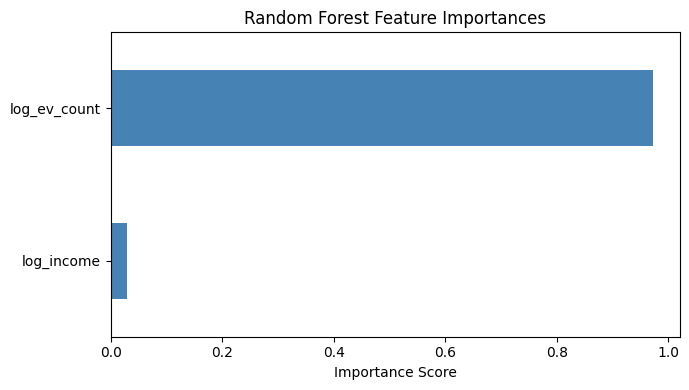

In [16]:
fig, ax = plt.subplots(figsize=(7,4))
importances.sort_values().plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Random Forest Feature Importances')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [17]:
df.to_csv('ev_equity_clean.csv', index=False)
print('Saved.')

Saved.
